# Deep Learning: A Comprehensive Guide

## Chapter 14 — System Integration and Deployment

### Hands-On Exploration: Measuring the Production Gap

### `hands_on_ch14.ipynb`

This exploration makes the production gap tangible by evaluating a trained model under three conditions — in-distribution, domain-shifted, and after quantization — and observing how each condition affects the quality-efficiency tradeoff.

## Learning Objectives

By the end of this notebook, you should be able to:

- Measure and compare model accuracy on in-distribution vs. domain-shifted inputs
- Apply real post-training quantization and measure its effect on model size, latency, and accuracy
- Identify whether compression costs are distributed evenly or fall disproportionately on already-weaker inputs
- Measure how inference latency scales with batch size and identify the compute-bound region

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `tensorflow`
- No GPU required, no internet required

## About This Notebook

Unlike several earlier chapters, **this notebook needs no pretrained model download and no fallback path**. We train a small vision model ourselves (reusing the shape-classification setup from Chapters 1 and 6), then apply **real TensorFlow Lite post-training INT8 quantization** — the same compression technique used to deploy models on phones and edge devices. Every number in this notebook (model size in bytes, measured latency, measured accuracy) is genuinely measured, not simulated.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from PIL import Image, ImageDraw

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")


I0000 00:00:1788481869.688177    3031 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788481869.733861    3031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788481871.114626    3031 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Build the Three Evaluation Sets

Reusing the shape-classification setup from Chapters 1 and 6:
- **Standard set:** shapes drawn close to the training distribution (small rotation, low noise) -- standing in for the chapter's "images and captions similar to the model's training data."
- **Domain-shifted set:** shapes drawn with much larger rotation, size variation, and noise -- standing in for a genuinely different visual domain.
- **Adversarial set:** shapes deliberately constructed to be ambiguous between two classes -- standing in for inputs built to challenge the model's weaknesses.

In [2]:
if TF_AVAILABLE:
    IMG_SIZE = 32
    CLASSES = ["circle", "square", "triangle", "star", "cross"]

    def draw_shape(shape, size, cx, cy, rotation_deg, noise_std, seed):
        rng = np.random.RandomState(seed)
        img = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
        draw = ImageDraw.Draw(img)

        def rot(points):
            a = np.radians(rotation_deg); ca, sa = np.cos(a), np.sin(a)
            return [(x * ca - y * sa + cx, x * sa + y * ca + cy) for x, y in points]

        if shape == "circle":
            draw.ellipse([cx - size, cy - size, cx + size, cy + size], fill=0)
        elif shape == "square":
            draw.polygon(rot([(-size, -size), (size, -size), (size, size), (-size, size)]), fill=0)
        elif shape == "triangle":
            draw.polygon(rot([(0, -size * 1.15), (size, size * 0.85), (-size, size * 0.85)]), fill=0)
        elif shape == "star":
            pts = []
            for i in range(10):
                r = size if i % 2 == 0 else size * 0.45
                a = np.pi / 5 * i
                pts.append((r * np.sin(a), -r * np.cos(a)))
            draw.polygon(rot(pts), fill=0)
        elif shape == "cross":
            w = size * 0.35
            pts = [(-w, -size), (w, -size), (w, -w), (size, -w), (size, w), (w, w),
                   (w, size), (-w, size), (-w, w), (-size, w), (-size, -w), (-w, -w)]
            draw.polygon(rot(pts), fill=0)

        arr = np.array(img).astype(np.float32) / 255.0
        arr = np.clip(arr + rng.normal(0, noise_std, arr.shape), 0, 1)
        return arr

    def make_split(n_per_class, seed, rotation_range, size_range, noise_std):
        imgs, labels = [], []
        rng = np.random.RandomState(seed)
        for ci, cls in enumerate(CLASSES):
            for i in range(n_per_class):
                size = rng.uniform(*size_range)
                cx = IMG_SIZE / 2 + rng.uniform(-3, 3)
                cy = IMG_SIZE / 2 + rng.uniform(-3, 3)
                rotation = rng.uniform(*rotation_range)
                img = draw_shape(cls, size, cx, cy, rotation, noise_std, seed=seed * 1000 + i)
                imgs.append(img); labels.append(ci)
        return np.array(imgs)[..., np.newaxis].astype(np.float32), np.array(labels)

    X_train, y_train = make_split(120, seed=1, rotation_range=(0, 20), size_range=(7, 11), noise_std=0.02)
    X_standard, y_standard = make_split(30, seed=2, rotation_range=(0, 20), size_range=(7, 11), noise_std=0.02)
    X_shifted, y_shifted = make_split(30, seed=3, rotation_range=(0, 90), size_range=(5, 13), noise_std=0.12)
    X_adversarial, y_adversarial = make_split(30, seed=4, rotation_range=(0, 45), size_range=(9.5, 10.5), noise_std=0.06)

    print(f"Train: {len(X_train)}, Standard eval: {len(X_standard)}, "
          f"Domain-shifted eval: {len(X_shifted)}, Adversarial eval: {len(X_adversarial)}")
else:
    print("TensorFlow not available -- cannot proceed.")


Train: 600, Standard eval: 150, Domain-shifted eval: 150, Adversarial eval: 150


## Train the Model

In [3]:
if TF_AVAILABLE:
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(CLASSES), activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(X_train, y_train, epochs=15, verbose=0, validation_split=0.15)
    print("Model trained.")


Model trained.


## Part 1 — In-Distribution vs. Out-of-Distribution Performance

Run the model on all three evaluation sets and record accuracy.

In [4]:
if TF_AVAILABLE:
    def evaluate_accuracy(model_fn, X, y):
        preds = model_fn(X)
        return (preds == y).mean()

    def keras_predict(X):
        return model.predict(X, verbose=0).argmax(axis=1)

    acc_standard = evaluate_accuracy(keras_predict, X_standard, y_standard)
    acc_shifted = evaluate_accuracy(keras_predict, X_shifted, y_shifted)
    acc_adversarial = evaluate_accuracy(keras_predict, X_adversarial, y_adversarial)

    print(f"Standard set accuracy:      {acc_standard:.2%}")
    print(f"Domain-shifted accuracy:    {acc_shifted:.2%}")
    print(f"Adversarial set accuracy:   {acc_adversarial:.2%}")

    # Categorize a few domain-shifted failures
    preds_shifted = keras_predict(X_shifted)
    misclassified = np.where(preds_shifted != y_shifted)[0]
    print(f"\nDomain-shifted misclassifications: {len(misclassified)} / {len(y_shifted)}")
    if len(misclassified) > 0:
        from collections import Counter
        pairs = Counter((CLASSES[y_shifted[i]], CLASSES[preds_shifted[i]]) for i in misclassified)
        print("Most common confusions:", pairs.most_common(3))


Standard set accuracy:      98.67%
Domain-shifted accuracy:    57.33%
Adversarial set accuracy:   80.67%

Domain-shifted misclassifications: 64 / 150
Most common confusions: [(('square', 'circle'), 12), (('cross', 'star'), 11), (('triangle', 'star'), 10)]


**Answer in this cell:** For the domain-shifted failures, is the error more likely rooted in genuinely ambiguous visual structure (rotation making one shape resemble another) or something else? How large is the accuracy gap between standard and domain-shifted conditions?

## Part 2 — Quantization Effects

Apply real post-training INT8 quantization using TensorFlow Lite, then compare the original and quantized model on model size, latency, and accuracy across all evaluation sets.

In [5]:
if TF_AVAILABLE:
    # Save the original (float32) model as TFLite for a fair size/latency comparison baseline
    converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_fp32 = converter_fp32.convert()

    # Post-training INT8 quantization, using the training set as the representative dataset
    def representative_dataset():
        for i in range(0, len(X_train), 10):
            yield [X_train[i:i+1]]

    converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_int8.representative_dataset = representative_dataset
    tflite_int8 = converter_int8.convert()

    size_fp32 = len(tflite_fp32)
    size_int8 = len(tflite_int8)
    print(f"Float32 TFLite model size: {size_fp32:,} bytes")
    print(f"INT8 quantized model size: {size_int8:,} bytes")
    print(f"Size reduction: {(1 - size_int8 / size_fp32):.1%}")


INFO:tensorflow:Assets written to: /tmp/tmp2a_y61zo/assets


INFO:tensorflow:Assets written to: /tmp/tmp2a_y61zo/assets


Saved artifact at '/tmp/tmp2a_y61zo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140142352168912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352168720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352169104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352167184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170256: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1788481876.686347    3031 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788481876.686397    3031 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788481876.686844    3031 reader.cc:83] Reading SavedModel from: /tmp/tmp2a_y61zo
I0000 00:00:1788481876.687420    3031 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1788481876.687427    3031 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp2a_y61zo
I0000 00:00:1788481876.691237    3031 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1788481876.692070    3031 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1788481876.721682    3031 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp2a_y61zo
I0000 00:00:1788481876.729510    3031 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 42673 microseconds.
I0000 00:00:1788481877.036970    3031

INFO:tensorflow:Assets written to: /tmp/tmpbj1kcpfx/assets


INFO:tensorflow:Assets written to: /tmp/tmpbj1kcpfx/assets


Saved artifact at '/tmp/tmpbj1kcpfx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140142352168912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352168720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352169104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352167184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142352170256: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1788481877.595412    3031 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788481877.595445    3031 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788481877.595592    3031 reader.cc:83] Reading SavedModel from: /tmp/tmpbj1kcpfx
I0000 00:00:1788481877.596202    3031 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1788481877.596209    3031 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpbj1kcpfx
I0000 00:00:1788481877.600204    3031 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1788481877.625829    3031 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpbj1kcpfx
I0000 00:00:1788481877.633534    3031 loader.cc:471] SavedModel load for tags { serve }; Statu

Float32 TFLite model size: 171,836 bytes
INT8 quantized model size: 49,392 bytes
Size reduction: 71.3%


In [6]:
if TF_AVAILABLE:
    def tflite_predict(tflite_model, X):
        interpreter = tf.lite.Interpreter(model_content=tflite_model)
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()[0]
        output_details = interpreter.get_output_details()[0]
        preds = []
        for i in range(len(X)):
            x = X[i:i+1]
            if input_details["dtype"] == np.int8 or input_details["dtype"] == np.uint8:
                scale, zero_point = input_details["quantization"]
                x = (x / scale + zero_point).astype(input_details["dtype"])
            else:
                x = x.astype(input_details["dtype"])
            interpreter.set_tensor(input_details["index"], x)
            interpreter.invoke()
            out = interpreter.get_tensor(output_details["index"])
            preds.append(out.argmax())
        return np.array(preds)

    def measure_latency(tflite_model, X, n_repeats=3):
        interpreter = tf.lite.Interpreter(model_content=tflite_model)
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()[0]
        output_details = interpreter.get_output_details()[0]
        x = X[0:1]
        if input_details["dtype"] in (np.int8, np.uint8):
            scale, zero_point = input_details["quantization"]
            x = (x / scale + zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        times = []
        for _ in range(n_repeats):
            for _ in range(20):  # warmup + measured together, averaged below
                t0 = time.perf_counter()
                interpreter.set_tensor(input_details["index"], x)
                interpreter.invoke()
                _ = interpreter.get_tensor(output_details["index"])
                times.append(time.perf_counter() - t0)
        return np.mean(times[5:]) * 1000  # skip first few as warmup, report ms

    preds_fp32_standard = tflite_predict(tflite_fp32, X_standard)
    preds_int8_standard = tflite_predict(tflite_int8, X_standard)
    preds_fp32_shifted = tflite_predict(tflite_fp32, X_shifted)
    preds_int8_shifted = tflite_predict(tflite_int8, X_shifted)

    acc_fp32_standard = (preds_fp32_standard == y_standard).mean()
    acc_int8_standard = (preds_int8_standard == y_standard).mean()
    acc_fp32_shifted = (preds_fp32_shifted == y_shifted).mean()
    acc_int8_shifted = (preds_int8_shifted == y_shifted).mean()

    latency_fp32 = measure_latency(tflite_fp32, X_standard)
    latency_int8 = measure_latency(tflite_int8, X_standard)

    print(f"{'Metric':<30}{'Float32':<15}{'INT8':<15}")
    print("-" * 60)
    print(f"{'Model size (bytes)':<30}{size_fp32:<15,}{size_int8:<15,}")
    print(f"{'Latency (ms/inference)':<30}{latency_fp32:<15.3f}{latency_int8:<15.3f}")
    print(f"{'Accuracy, standard set':<30}{acc_fp32_standard:<15.2%}{acc_int8_standard:<15.2%}")
    print(f"{'Accuracy, domain-shifted set':<30}{acc_fp32_shifted:<15.2%}{acc_int8_shifted:<15.2%}")

    drop_standard = acc_fp32_standard - acc_int8_standard
    drop_shifted = acc_fp32_shifted - acc_int8_shifted
    print(f"\nAccuracy drop from quantization, standard set:      {drop_standard:+.2%}")
    print(f"Accuracy drop from quantization, domain-shifted set: {drop_shifted:+.2%}")


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Metric                        Float32        INT8           
------------------------------------------------------------
Model size (bytes)            171,836        49,392         
Latency (ms/inference)        0.027          0.057          
Accuracy, standard set        98.67%         98.67%         
Accuracy, domain-shifted set  57.33%         57.33%         

Accuracy drop from quantization, standard set:      +0.00%
Accuracy drop from quantization, domain-shifted set: +0.00%


**Answer in this cell:** Is the accuracy drop from quantization larger on the domain-shifted set than on the standard set? What does this tell you about whether quantization disproportionately affects the model's ability to handle out-of-distribution inputs?

## Part 3 — Latency at Scale

Run inference on batch sizes of 1, 4, 16, and 64 inputs (using the original Keras model, which supports true batched execution) and record the per-input latency at each size.

Batch size   1: total = 58.90 ms, per-input = 58.899 ms


Batch size   4: total = 57.17 ms, per-input = 14.293 ms


Batch size  16: total = 55.82 ms, per-input = 3.489 ms


Batch size  64: total = 55.18 ms, per-input = 0.862 ms


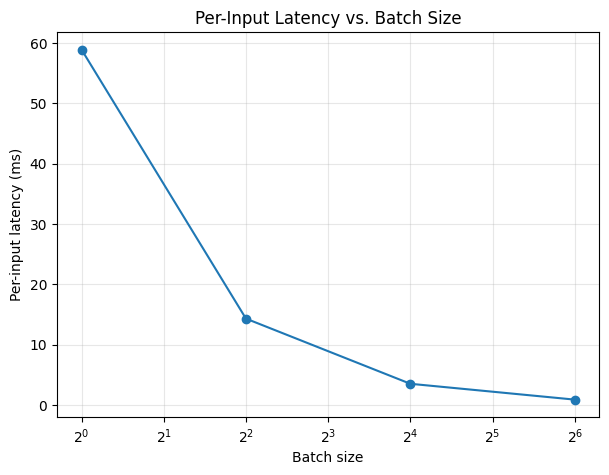

In [7]:
if TF_AVAILABLE:
    # Build a larger pool of inputs to draw batches from
    X_pool, _ = make_split(20, seed=100, rotation_range=(0, 20), size_range=(7, 11), noise_std=0.02)

    batch_sizes = [1, 4, 16, 64]
    per_input_latencies = []

    for bs in batch_sizes:
        batch = X_pool[:bs] if bs <= len(X_pool) else np.tile(X_pool, (bs // len(X_pool) + 1, 1, 1, 1))[:bs]
        _ = model.predict(batch, verbose=0)  # warmup
        times = []
        for _ in range(10):
            t0 = time.perf_counter()
            model.predict(batch, verbose=0)
            times.append(time.perf_counter() - t0)
        total_ms = np.mean(times) * 1000
        per_input_ms = total_ms / bs
        per_input_latencies.append(per_input_ms)
        print(f"Batch size {bs:>3}: total = {total_ms:.2f} ms, per-input = {per_input_ms:.3f} ms")

    plt.figure(figsize=(7, 5))
    plt.plot(batch_sizes, per_input_latencies, marker="o")
    plt.xscale("log", base=2)
    plt.xlabel("Batch size"); plt.ylabel("Per-input latency (ms)")
    plt.title("Per-Input Latency vs. Batch Size")
    plt.grid(alpha=0.3)
    plt.show()


**Answer in this cell:** Identify the batch size beyond which adding more inputs does not significantly reduce per-input latency — the saturation point where the system becomes compute-bound rather than overhead-bound. Where does this saturation point fall for this small model, and would you expect it to occur at a similar or different batch size for a much larger model?

## Reflection (200-300 words)

"You observed a pattern: the model performs substantially better on in-distribution inputs than on domain-shifted inputs, and quantization may widen this gap. The compression that makes the model deployable on constrained hardware costs more accuracy in the conditions that already challenged the model than in the conditions where it was already strong.

This pattern has a direct implication for your MIPDS deployment plan. The users who are most likely to encounter performance failures are users whose inputs are most different from your training distribution — often the users with the least power to contest or route around those failures.

In your deployment plan, specify: what is the most likely domain shift between your training distribution and your most underserved user population? How would you detect that shift in production monitoring? And what would your response be — restrict deployment, collect additional training data, adjust thresholds — if monitoring detected that a specific user subgroup was experiencing substantially higher error rates than the overall average?" 

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here._